# Telecom Customer Churn Prediction

## Project Overview

Customer churn is a significant challenge for telecommunications companies because customer loss can reduce revenue and long-term business stability. This project uses machine learning to identify customers who are at risk of churning based on customer demographics, account information, services, and billing characteristics.

The project compares **Logistic Regression**, **Random Forest**, and **XGBoost** models to evaluate their effectiveness in predicting customer churn and identifying important factors associated with customer attrition.

### Project Outputs

This notebook automatically saves:
- Generated visualizations to the `figures/` folder
- Model performance and feature results to the `results/` folder


## 1. Import Libraries

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

os.environ["LOKY_MAX_CPU_COUNT"] = "4"

pd.set_option("display.max_columns", None)


## 2. Set Project Paths

In [2]:
# This notebook is expected to be stored in:
# Telecom_Churn_Prediction/notebooks/Telecom_Churn_Prediction.ipynb

CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)


Project directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Telecom_Churn_Prediction
Data directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Telecom_Churn_Prediction\data
Figures directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Telecom_Churn_Prediction\figures
Results directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Telecom_Churn_Prediction\results


## 3. Load and Inspect the Dataset

In [3]:
possible_names = [
    "Telco-Customer-Churn.csv",
    "WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

dataset_path = None

for filename in possible_names:
    candidate = DATA_DIR / filename
    if candidate.exists():
        dataset_path = candidate
        break

if dataset_path is None:
    csv_files = list(DATA_DIR.glob("*.csv"))
    if len(csv_files) == 1:
        dataset_path = csv_files[0]
    else:
        raise FileNotFoundError(
            f"Could not locate the churn dataset in {DATA_DIR}"
        )

df = pd.read_csv(dataset_path)

print("Dataset:", dataset_path.name)
print("Shape:", df.shape)

display(df.head())


Dataset: Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Information")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing Values")
display(df.isna().sum().to_frame("Missing Values"))


Dataset Information


,Data Type
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing Values


,Missing Values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 4. Data Cleaning and Preparation

In [5]:
# Remove non-predictive identifier
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Replace blank strings with missing values
df = df.replace(r"^\s*$", np.nan, regex=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges values with the median
if df["TotalCharges"].isna().any():
    median_total_charges = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(
        median_total_charges
    )
    print(
        "Filled missing TotalCharges values with median:",
        round(median_total_charges, 2)
    )

# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

display(df.head())


Filled missing TotalCharges values with median: 1397.48


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Feature Engineering

In [6]:
# Log-transformed charge variables
df["MonthlyCharges_log"] = np.log1p(df["MonthlyCharges"])
df["TotalCharges_log"] = np.log1p(df["TotalCharges"])

# Group customer tenure into broader categories
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 year"
    elif tenure <= 24:
        return "1-2 years"
    elif tenure <= 48:
        return "2-4 years"
    elif tenure <= 60:
        return "4-5 years"
    return "5+ years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

# Simplify payment method categories
df["PaymentMethod"] = df["PaymentMethod"].replace(
    {
        "Bank transfer (automatic)": "Automatic Payment",
        "Credit card (automatic)": "Automatic Payment",
        "Mailed check": "Mailed Check",
        "Electronic check": "Electronic Check",
    }
)

display(df.head())


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyCharges_log,TotalCharges_log,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic Check,29.85,29.85,0,3.429137,3.429137,0-1 year
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,56.95,1889.50,0,4.059581,7.544597,2-4 years
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed Check,53.85,108.15,1,4.004602,4.692723,0-1 year
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Automatic Payment,42.30,1840.75,0,3.768153,7.518471,2-4 years
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic Check,70.70,151.65,1,4.272491,5.028148,0-1 year


## 6. Handle Outliers

In [7]:
for col in ["MonthlyCharges", "TotalCharges"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df[col] = np.clip(
        df[col],
        lower_bound,
        upper_bound
    )

print("Outlier handling completed.")


Outlier handling completed.


## 7. Encode and Scale Features

In [8]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = [
    col
    for col in df.select_dtypes(
        include=["int64", "float64"]
    ).columns
    if col != "Churn"
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

scaler = MinMaxScaler()
df_encoded[numerical_columns] = scaler.fit_transform(
    df_encoded[numerical_columns]
)

# Convert Boolean dummy columns to integers
bool_columns = df_encoded.select_dtypes(
    include=["bool"]
).columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print("Encoded dataset shape:", df_encoded.shape)
display(df_encoded.head())


Encoded dataset shape: (7043, 36)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,MonthlyCharges_log,TotalCharges_log,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,TenureGroup_1-2 years,TenureGroup_2-4 years,TenureGroup_4-5 years,TenureGroup_5+ years
0,0.0,0.013889,0.115423,0.001275,0,0.258016,0.072892,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
1,0.0,0.472222,0.385075,0.215867,0,0.602917,0.749358,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0
2,0.0,0.027778,0.354229,0.010310,1,0.572840,0.280590,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
3,0.0,0.625000,0.239303,0.210241,0,0.443484,0.745063,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0.0,0.027778,0.521891,0.015330,1,0.719396,0.335724,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0


## 8. Train-Test Split and SMOTE

In [9]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(
    X_train,
    y_train
)

print("Training rows before SMOTE:", len(X_train))
print("Training rows after SMOTE: ", len(X_train_sm))
print("Test rows:                 ", len(X_test))


Training rows before SMOTE: 5634
Training rows after SMOTE:  8278
Test rows:                  1409


## 9. Evaluation Functions

In [10]:
def calculate_metrics(y_true, y_pred, y_probability):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true, y_probability
        ),
    }


def save_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    file_stem
):
    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax
    )

    ax.set_title(
        f"Confusion Matrix - {model_name}"
    )

    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{file_stem}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def save_roc_curve(
    y_true,
    y_probability,
    model_name,
    file_stem
):
    fpr, tpr, _ = roc_curve(
        y_true,
        y_probability
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(
        fpr,
        tpr,
        label=model_name
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - {model_name}")
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{file_stem}_roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def save_probability_distribution(
    y_true,
    y_probability,
    model_name,
    file_stem
):
    y_true_array = np.asarray(y_true)

    fig, ax = plt.subplots(figsize=(6, 4))

    sns.histplot(
        y_probability[y_true_array == 0],
        label="No Churn",
        kde=True,
        stat="density",
        bins=30,
        ax=ax
    )

    sns.histplot(
        y_probability[y_true_array == 1],
        label="Churn",
        kde=True,
        stat="density",
        bins=30,
        ax=ax
    )

    ax.set_xlabel(
        "Predicted Churn Probability"
    )
    ax.set_ylabel("Density")
    ax.set_title(
        f"Predicted Probability Distribution - {model_name}"
    )
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{file_stem}_probability_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def save_probability_scatter(
    y_true,
    y_probability,
    model_name,
    file_stem
):
    y_true_array = np.asarray(y_true)

    fig, ax = plt.subplots(figsize=(7, 4))

    scatter = ax.scatter(
        range(len(y_true_array)),
        y_probability,
        c=y_true_array,
        cmap="bwr",
        alpha=0.6
    )

    ax.set_xlabel("Sample Index")
    ax.set_ylabel(
        "Predicted Probability of Churn"
    )
    ax.set_title(
        f"Predicted Probability vs Actual Churn - {model_name}"
    )

    legend = ax.legend(
        *scatter.legend_elements(),
        title="Actual Churn",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    legend_texts = legend.get_texts()
    if len(legend_texts) >= 2:
        legend_texts[0].set_text("No Churn")
        legend_texts[1].set_text("Churn")

    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{file_stem}_probability_scatter.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


def evaluate_model(
    model,
    model_name,
    file_stem
):
    model.fit(
        X_train_sm,
        y_train_sm
    )

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    metrics = calculate_metrics(
        y_test,
        y_pred,
        y_probability
    )

    print(model_name)
    print("-" * len(model_name))

    for metric_name, metric_value in metrics.items():
        print(
            f"{metric_name:10}: "
            f"{metric_value:.4f}"
        )

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred,
            digits=4,
            zero_division=0
        )
    )

    save_confusion_matrix(
        y_test,
        y_pred,
        model_name,
        file_stem
    )

    save_roc_curve(
        y_test,
        y_probability,
        model_name,
        file_stem
    )

    save_probability_distribution(
        y_test,
        y_probability,
        model_name,
        file_stem
    )

    save_probability_scatter(
        y_test,
        y_probability,
        model_name,
        file_stem
    )

    return model, metrics


## 10. Logistic Regression

Logistic Regression
-------------------
Accuracy  : 0.7559
Precision : 0.5281
Recall    : 0.7540
F1        : 0.6211
ROC_AUC   : 0.8415

Classification Report
              precision    recall  f1-score   support

           0     0.8949    0.7565    0.8199      1035
           1     0.5281    0.7540    0.6211       374

    accuracy                         0.7559      1409
   macro avg     0.7115    0.7553    0.7205      1409
weighted avg     0.7975    0.7559    0.7671      1409



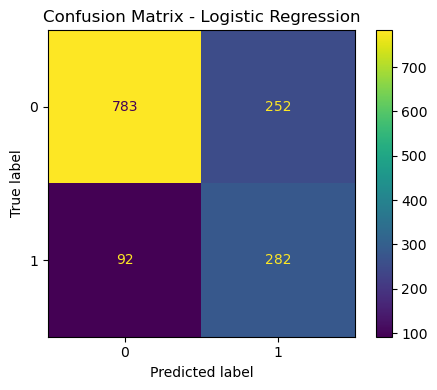

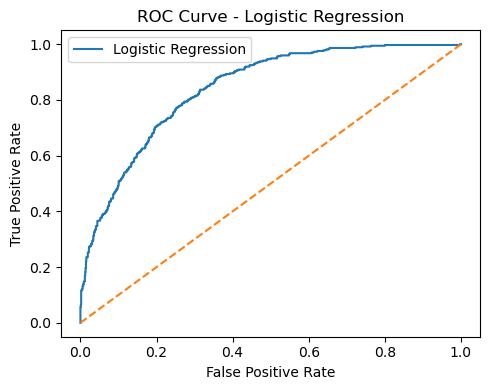

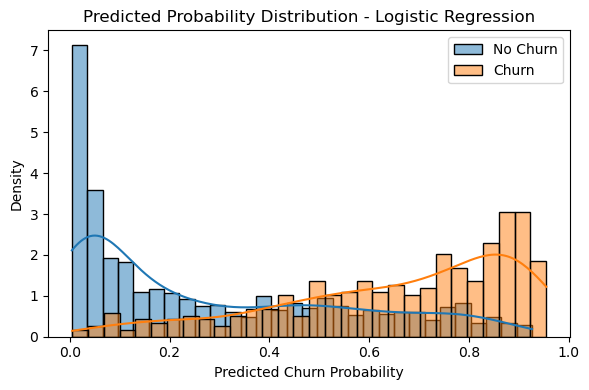

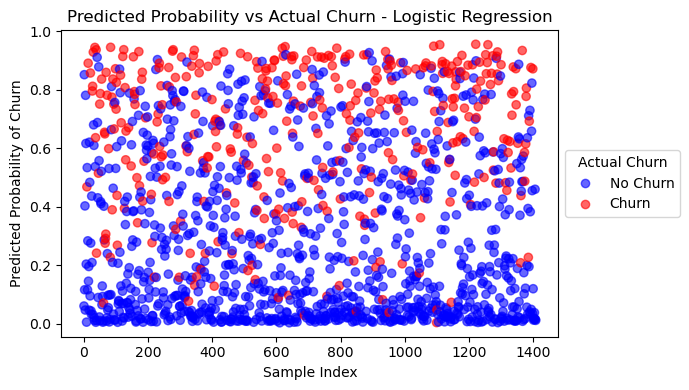

In [11]:
logistic_regression = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

logistic_regression, lr_metrics = evaluate_model(
    logistic_regression,
    "Logistic Regression",
    "logistic_regression"
)


In [12]:
logistic_coefficients = pd.DataFrame(
    {
        "feature": X_train_sm.columns,
        "coefficient": logistic_regression.coef_[0]
    }
)

logistic_coefficients["odds_ratio"] = np.exp(
    logistic_coefficients["coefficient"]
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="coefficient",
    ascending=False
)

logistic_coefficients.to_csv(
    RESULTS_DIR / "logistic_regression_coefficients.csv",
    index=False
)

display(logistic_coefficients.head(15))


,feature,coefficient,odds_ratio
2,MonthlyCharges,10.368503,31840.776895
4,MonthlyCharges_log,4.160193,64.083896
3,TotalCharges,2.531488,12.572196
1,tenure,0.760234,2.138777
13,InternetService_No,0.445788,1.561721
14,OnlineSecurity_No internet service,0.445788,1.561721
24,StreamingMovies_No internet service,0.445788,1.561721
22,StreamingTV_No internet service,0.445788,1.561721
20,TechSupport_No internet service,0.445788,1.561721
18,DeviceProtection_No internet service,0.445788,1.561721


## 11. Random Forest

Random Forest
-------------
Accuracy  : 0.7637
Precision : 0.5469
Recall    : 0.6390
F1        : 0.5894
ROC_AUC   : 0.8255

Classification Report
              precision    recall  f1-score   support

           0     0.8611    0.8087    0.8341      1035
           1     0.5469    0.6390    0.5894       374

    accuracy                         0.7637      1409
   macro avg     0.7040    0.7239    0.7117      1409
weighted avg     0.7777    0.7637    0.7691      1409



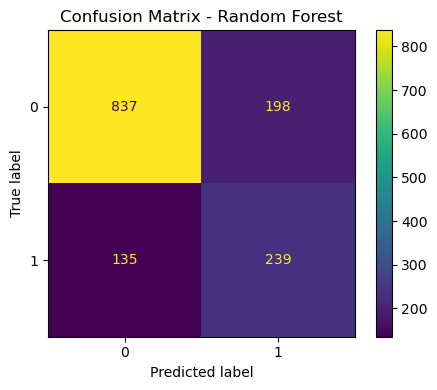

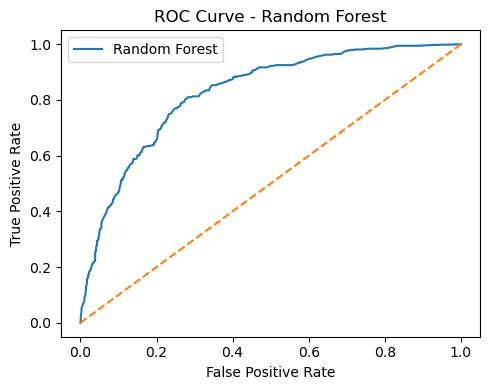

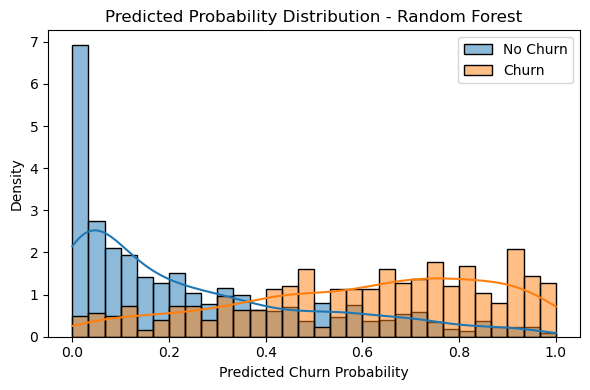

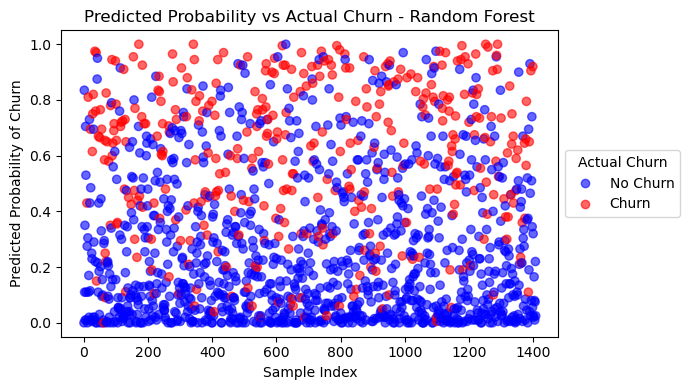

In [13]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest, rf_metrics = evaluate_model(
    random_forest,
    "Random Forest",
    "random_forest"
)


In [14]:
rf_importance = pd.DataFrame(
    {
        "feature": X_train_sm.columns,
        "importance": random_forest.feature_importances_
    }
).sort_values(
    by="importance",
    ascending=False
)

rf_importance.to_csv(
    RESULTS_DIR / "random_forest_feature_importance.csv",
    index=False
)

display(rf_importance.head(15))


,feature,importance
1,tenure,0.123228
5,TotalCharges_log,0.106593
3,TotalCharges,0.102839
2,MonthlyCharges,0.097415
4,MonthlyCharges_log,0.094374
27,Contract_Two year,0.055489
12,InternetService_Fiber optic,0.034830
26,Contract_One year,0.033152
15,OnlineSecurity_Yes,0.031936
21,TechSupport_Yes,0.028755


## 12. XGBoost

XGBoost
-------
Accuracy  : 0.7630
Precision : 0.5395
Recall    : 0.7299
F1        : 0.6205
ROC_AUC   : 0.8358

Classification Report
              precision    recall  f1-score   support

           0     0.8882    0.7749    0.8277      1035
           1     0.5395    0.7299    0.6205       374

    accuracy                         0.7630      1409
   macro avg     0.7138    0.7524    0.7241      1409
weighted avg     0.7956    0.7630    0.7727      1409



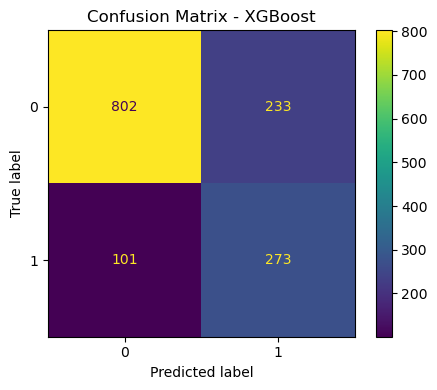

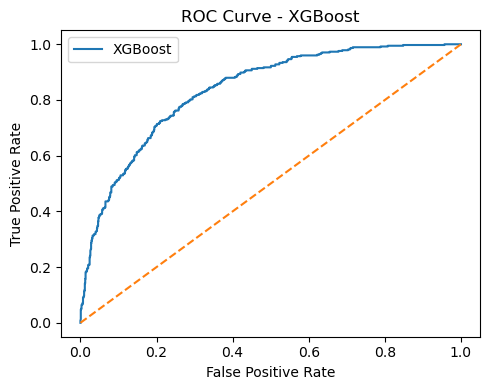

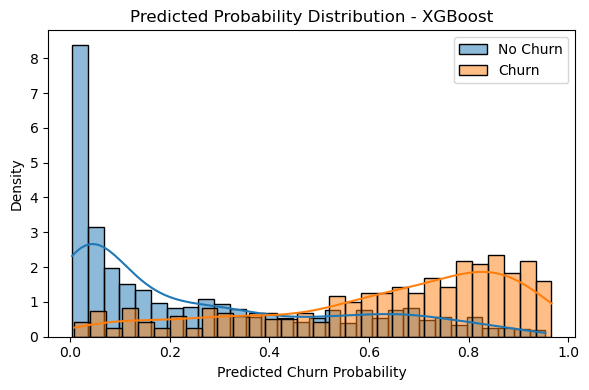

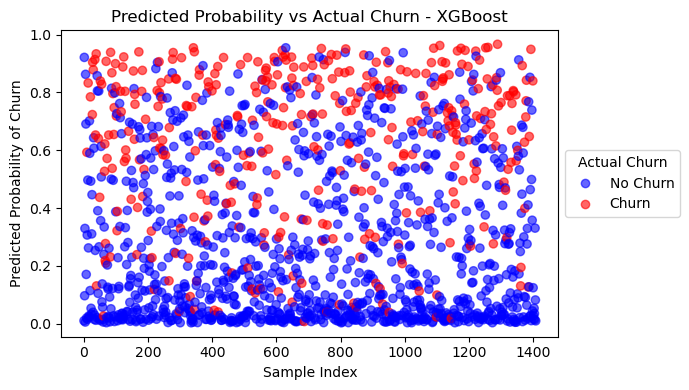

In [15]:
xgboost = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgboost, xgb_metrics = evaluate_model(
    xgboost,
    "XGBoost",
    "xgboost"
)


In [16]:
xgb_importance = pd.DataFrame(
    {
        "feature": X_train_sm.columns,
        "importance": xgboost.feature_importances_
    }
).sort_values(
    by="importance",
    ascending=False
)

xgb_importance.to_csv(
    RESULTS_DIR / "xgboost_feature_importance.csv",
    index=False
)

display(xgb_importance.head(15))


,feature,importance
27,Contract_Two year,0.302842
14,OnlineSecurity_No internet service,0.157186
26,Contract_One year,0.111601
12,InternetService_Fiber optic,0.080097
13,InternetService_No,0.066167
15,OnlineSecurity_Yes,0.028440
1,tenure,0.020361
21,TechSupport_Yes,0.018049
8,Dependents_Yes,0.017287
0,SeniorCitizen,0.015568


## 13. Model Comparison

In [17]:
model_performance = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            **lr_metrics
        },
        {
            "Model": "Random Forest",
            **rf_metrics
        },
        {
            "Model": "XGBoost",
            **xgb_metrics
        }
    ]
)

model_performance.to_csv(
    RESULTS_DIR / "model_performance.csv",
    index=False
)

display(
    model_performance.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "ROC_AUC": "{:.4f}"
        }
    )
)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7559,0.5281,0.7540,0.6211,0.8415
1,Random Forest,0.7637,0.5469,0.6390,0.5894,0.8255
2,XGBoost,0.7630,0.5395,0.7299,0.6205,0.8358


## 14. Saved Project Outputs

In [18]:
print("Figures saved:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", file.name)

print("\nResult files saved:")
for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", file.name)


Figures saved:
 - logistic_regression_confusion_matrix.png
 - logistic_regression_probability_distribution.png
 - logistic_regression_probability_scatter.png
 - logistic_regression_roc_curve.png
 - random_forest_confusion_matrix.png
 - random_forest_probability_distribution.png
 - random_forest_probability_scatter.png
 - random_forest_roc_curve.png
 - xgboost_confusion_matrix.png
 - xgboost_probability_distribution.png
 - xgboost_probability_scatter.png
 - xgboost_roc_curve.png

Result files saved:
 - logistic_regression_coefficients.csv
 - model_performance.csv
 - random_forest_feature_importance.csv
 - xgboost_feature_importance.csv


## Conclusion

This project applies three classification techniques to predict telecom customer churn and compares their performance using accuracy, precision, recall, F1 score, and ROC-AUC. The generated model outputs, visualizations, coefficients, and feature importance results are saved separately so they can also be used in the project's GitHub README and portfolio presentation.
